# Unsupervised Learning in R - Part A

## About the Dataset
This is a dataset extracted from Domo ETL process. Create a customers-history table with the following history about their rentals: number of movies rented, average days out, average hours out, distinct weeks visited in a year [you can get this by converting rental_date to week of the year and counting distinct when aggregating]. (optional: can you think of any other customer variables you might add?). 

Next we are going to importt the table created into R from Domo. Domo has a nifty R plugin you can find out more about here: https://www.domo.com/domopalooza/resources/harnessing-the-power-of-domos-r-plugin

NOTE
Previous labs involved using data directly from the operational database (in Google Cloud) while this lab uses data that has been STAGED witin an Enterprise Data Warehouse (DOMO) specifically for an analytical task. 

## Task
Run a K-means cluster to assign customers to different groups based on their history. 

[See more about K-Means Clustering: ](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)


## First, we have to get Datalab talking with Github where the rdomo package is located

In [6]:
library(devtools)
library(usethis)


## Start the Lab

In [2]:
#install the rdomo plugin from Domo's github account. If this does not work, we will download the notebook and run it in Google Colab (also free, allows you run R-code in the cloud)

devtools::install_github(repo='domoinc/rdomo',ref='main')


Warning message in gitcreds_get_cache(cache_ev):
“Invalid gitcreds credentials in env var `GITHUB_PAT_GITHUB_COM`. Maybe an unescaped ':' character?”
Warning message in gitcreds_get_cache(cache_ev):
“Invalid gitcreds credentials in env var `GITHUB_PAT_GITHUB_COM`. Maybe an unescaped ':' character?”
Warning message in gitcreds_get_cache(cache_ev):
“Invalid gitcreds credentials in env var `GITHUB_PAT_GITHUB_COM`. Maybe an unescaped ':' character?”


ERROR: Error: Failed to install 'unknown package' from GitHub:
  HTTP error 403.
  API rate limit exceeded for 3.233.97.1. (But here's the good news: Authenticated requests get a higher rate limit. Check out the documentation for more details.)

  Rate limit remaining: 0/60
  Rate limit reset at: 2025-02-27 03:49:09 UTC

  To increase your GitHub API rate limit
  - Use `usethis::create_github_token()` to create a Personal Access Token.
  - Use `gitcreds::gitcreds_set()` to add the token.


In [3]:
#provide a connection string to domo
#follow the following steps to create a connection string for your own account.

# visit https://developer.domo.com/portal/d01f63a6ba662-domo-developer-portal
# select 'Dev Portal Login'
# supply the name of the classroom Domo instance: domo-classroom-uofu-dagogo
# logon by supplying your username and password
# Select 'create a client'
# provide a meaningful name and description e.g. is6481 access
# Make sure that 'data' is selected under 'application scope'
# Click on create and copy the client_id and secret key to replace the one shown below

domo <- rdomo::Domo(client_id='',secret='')


ERROR: Error in loadNamespace(x): there is no package called ‘rdomo’


In [4]:
#retrieves all the datasets in your account to a table

dataset_name <- domo$ds_list()

In [5]:
head(dataset_name)

id                                  
1 eaadf3b2-2829-4646-be3b-36dc363dd617
2 173f5a55-1367-4ab3-9be1-43cec9131e7a
3 97c0e1e2-b711-4d29-a3e5-cb5b86138f64
4 0b1dd6da-4e64-4220-8ced-b7def5e8da6e
5 9450d98e-a7fc-4a18-8155-493d55f53d1f
6 4747a19c-75b2-4bbc-a4b5-b3afef06a128
  name                                             description rows    columns
1 Analytics_mindset_case_studies_ETLinR_States.csv                 442  4     
2 Analytics_mindset_case_studies_ETLinR_Swift.csv              1049961 19     
3 customer_history                                 NA              599  4     
4 dvdrental - inventory                                           4581  6     
5 dvdrental - payment                                            14596  8     
6 dvdrental - rental                                             16044  9     
  owner     <NA>        <NA>      <NA>        <NA>      <NA>        <NA>     
1 675765384 David Agogo 675765384 David Agogo 675765384 David Agogo 675765384
2 675765384 David Agogo 675765384 David Agogo 675765384 David Agogo 675765384
3 675765384 David Agogo 675765384 David Agogo 675765384 David Agogo 675765384
4 675765384 David Agogo 675765384 David Agogo 675765384 David Agogo 675765384
5 675765384 David Agogo 675765384 David Agogo 675765384 David Agogo 675765384
6 675765384 David Agogo 675765384 David Agogo 675765384 David Agogo 675765384
  <NA>        <NA>      <NA>        <NA>      <NA>        dataCurrentAt       
1 David Agogo 675765384 David Agogo 675765384 David Agogo 2024-08-19T20:05:11Z
2 David Agogo 675765384 David Agogo 675765384 David Agogo 2024-08-19T20:09:27Z
3 David Agogo 675765384 David Agogo 675765384 David Agogo 2024-08-23T02:43:21Z
4 David Agogo 675765384 David Agogo 675765384 David Agogo 2024-08-23T01:53:19Z
5 David Agogo 675765384 David Agogo 675765384 David Agogo 2024-08-23T01:51:59Z
6 David Agogo 675765384 David Agogo 675765384 David Agogo 2024-08-23T01:54:35Z
  createdAt            updatedAt            pdpEnabled
1 2024-08-19T20:05:01Z 2024-08-19T20:05:11Z FALSE     
2 2024-08-19T20:01:52Z 2024-08-19T20:09:28Z FALSE     
3 2024-08-23T02:43:09Z 2024-08-23T02:43:22Z FALSE     
4 2024-08-23T01:53:12Z 2024-08-23T01:53:19Z FALSE     
5 2024-08-23T01:51:52Z 2024-08-23T01:51:59Z FALSE     
6 2024-08-23T01:54:28Z 2024-08-23T01:54:35Z FALSE

In [6]:
#I am selecting a table called customer_history from my account. You will have to edit this for yourself and select the name of a table in your account

customer_history_id <- dataset_name[dataset_name$name == "customer_history", "id"] #edit 'customer_history' and provide your own table name

#customer_history_id <- customer_history_id[1,] #selecting the first value (if necessary)
customer_history_id

id
<chr>
97c0e1e2-b711-4d29-a3e5-cb5b86138f64


In [7]:
#the ds_get() command retrieves data from domo into R

data1 <- domo$ds_get(customer_history_id)
data1_info <- domo$ds_meta(customer_history_id)


No encoding supplied: defaulting to UTF-8.

Rows: 599 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (4): customer_id, total_payment, rental_count, unique_days

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
print(data1_info)

$id
[1] "97c0e1e2-b711-4d29-a3e5-cb5b86138f64"

$name
[1] "customer_history"

$rows
[1] 599

$columns
[1] 4

$schema
$schema$columns
$schema$columns[[1]]
$schema$columns[[1]]$type
[1] "LONG"

$schema$columns[[1]]$name
[1] "customer_id"


$schema$columns[[2]]
$schema$columns[[2]]$type
[1] "DOUBLE"

$schema$columns[[2]]$name
[1] "total_payment"


$schema$columns[[3]]
$schema$columns[[3]]$type
[1] "LONG"

$schema$columns[[3]]$name
[1] "rental_count"


$schema$columns[[4]]
$schema$columns[[4]]$type
[1] "LONG"

$schema$columns[[4]]$name
[1] "unique_days"




$owner
$owner$id
[1] 675765384

$owner$name
[1] "David Agogo"


$dataCurrentAt
[1] "2024-08-23T02:43:21Z"

$createdAt
[1] "2024-08-23T02:43:09Z"

$updatedAt
[1] "2024-08-23T02:43:22Z"

$pdpEnabled
[1] FALSE

$policies
$policies[[1]]
$policies[[1]]$id
[1] 11

$policies[[1]]$type
[1] "open"

$policies[[1]]$name
[1] "All Rows"

$policies[[1]]$filters
list()

$policies[[1]]$users
list()

$policies[[1]]$virtualUsers
list()

$policies[[1]]$gr

In [17]:
print(data1)

# A tibble: 599 × 4
   customer_id total_payment rental_count unique_days
         <dbl>         <dbl>        <dbl>       <dbl>
 1         341           104           22          16
 2         342           131           32          15
 3         343           107           23          15
 4         344            65           16          12
 5         345           105           21          15
 6         346           146           30          15
 7         347           143           30          17
 8         348           145           34          19
 9         349           134           28          18
10         350            64           21          13
# ℹ 589 more rows


In [ ]:
# Load necessary libraries
library(dplyr)
library(ggplot2)
library(cluster)


# Remove customer_id from data1
customer_ids <- data1$customer_id

df1 <- data1 %>% select(-customer_id)



In [ ]:

# Standardize the data
df1_scaled <- scale(df1)


In [ ]:

# Determine the optimal number of clusters using the Elbow method
wss <- (nrow(df1_scaled)-1)*sum(apply(df1_scaled, 2, var))
for (i in 2:15) wss[i] <- sum(kmeans(df1_scaled, centers=i)$withinss)

# Plot the Elbow method
plot(1:15, wss, type="b", xlab="Number of Clusters", ylab="Within groups sum of squares")


In [ ]:

# Set the number of clusters
num_clusters <- 4  # This can be adjusted based on the Elbow plot


In [ ]:

# Run kmeans clustering
set.seed(123)  # For reproducibility

kmeans_result <- kmeans(df1_scaled, centers=num_clusters, nstart=25)


Don't know how to automatically pick scale for object of type
<tbl_df/tbl/data.frame>. Defaulting to continuous.
Don't know how to automatically pick scale for object of type
<tbl_df/tbl/data.frame>. Defaulting to continuous.
ERROR while rich displaying an object: Error in `data[[var]][scale_index[[i]]]`:
! Can't subset columns past the end.
ℹ Locations 2, 3, 4, …, 598, and 599 don't exist.
ℹ There is only 1 column.

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2rep

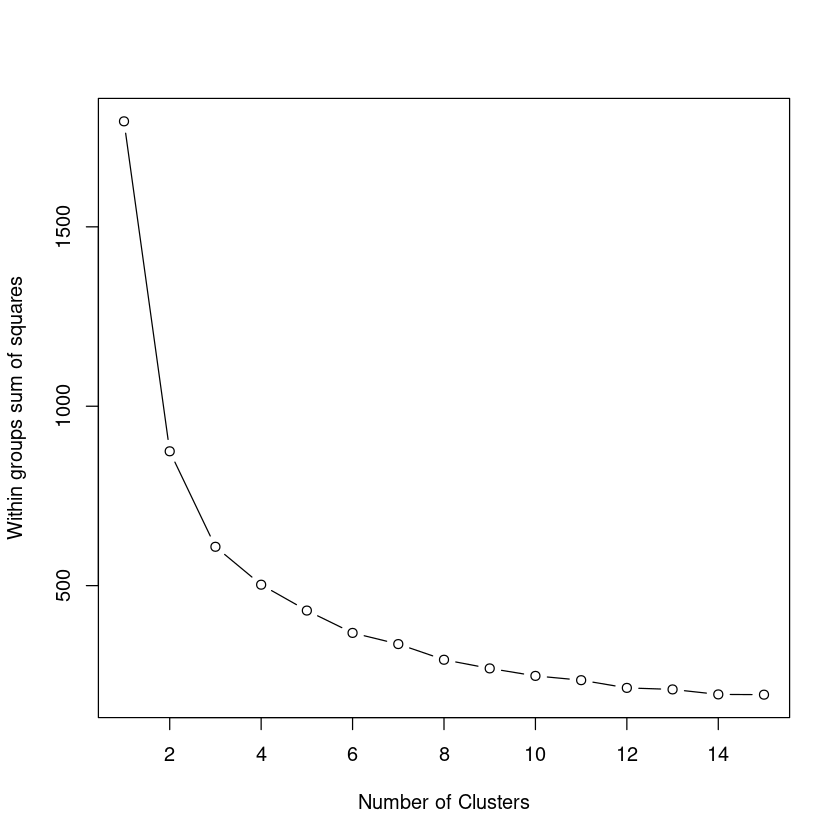

In [18]:

# Add the cluster assignments to the original data
df1$cluster <- kmeans_result$cluster

#return customer ids
df1$customer_id <- customer_ids



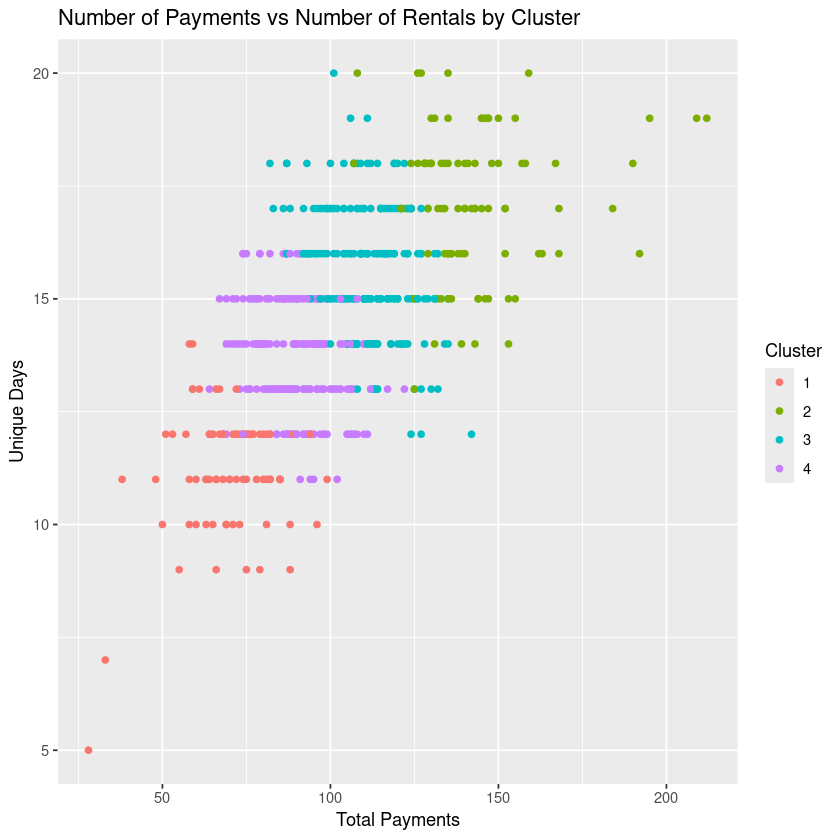

In [19]:
# Plot number_of_payments vs number_of_rentals
ggplot(df1, aes(x = total_payment, y = unique_days, color = factor(cluster))) +
  geom_point() +
  labs(title = "Number of Payments vs Number of Rentals by Cluster", x = "Total Payments", y = "Unique Days", color = "Cluster")

In [20]:
# Load necessary library
library(dplyr)

# Calculate the means for each cluster
cluster_means <- df1 %>%
  group_by(cluster) %>%
  summarise(across(everything(), mean, na.rm = TRUE))

# Display the means for each cluster
cluster_means

cluster,total_payment,rental_count,unique_days,customer_id
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,70.18824,17.12941,11.22353,319.9882
2,142.80435,32.15217,17.09783,271.7500
3,110.69048,26.29048,15.64762,316.4238
4,90.13679,21.98585,13.60849,287.9764


In [25]:
#this will create a new dataset in domo called 'customer_history_withclusters_spr25'

df1_domo <- domo$ds_create(df1, "customer_history_withclusters_spr25", update_method = "REPLACE")
print(df1_domo)

[1] "92782a8f-c7f1-4f0d-82e7-5b928af75ccc"
